# CNN Architecture and Training

## Start with a question that the image structure can answer

Suppose we want to distinguish images containing a vertical line from images containing a horizontal line. A useful classifier must respond to orientation while tolerating different line locations and a little measurement noise.

A **convolutional neural network (CNN)** applies shared local filters, nonlinear activations, and later feature combinations before producing class scores. Its architecture defines the path from pixels to those scores. Training adjusts the parameters using examples and a loss.

The [code companion](34_CNN_Architecture_and_Training.ipynb) builds a small local dataset and trains a two-convolution classifier. We will trace its exact shapes and parameters, calculate a prediction and update with a smaller head, and distinguish fitting from evaluating a held-out distribution.

The goal is to understand how the pieces work together. A successful synthetic line classifier would not establish recognition of arbitrary objects, robust performance on photographs, or usefulness outside its generated data. [Convolution by Hand](33_Convolution_by_Hand_Notes.ipynb) provides the local-filter arithmetic used underneath this lesson.


## Inspect the synthetic images and their labels

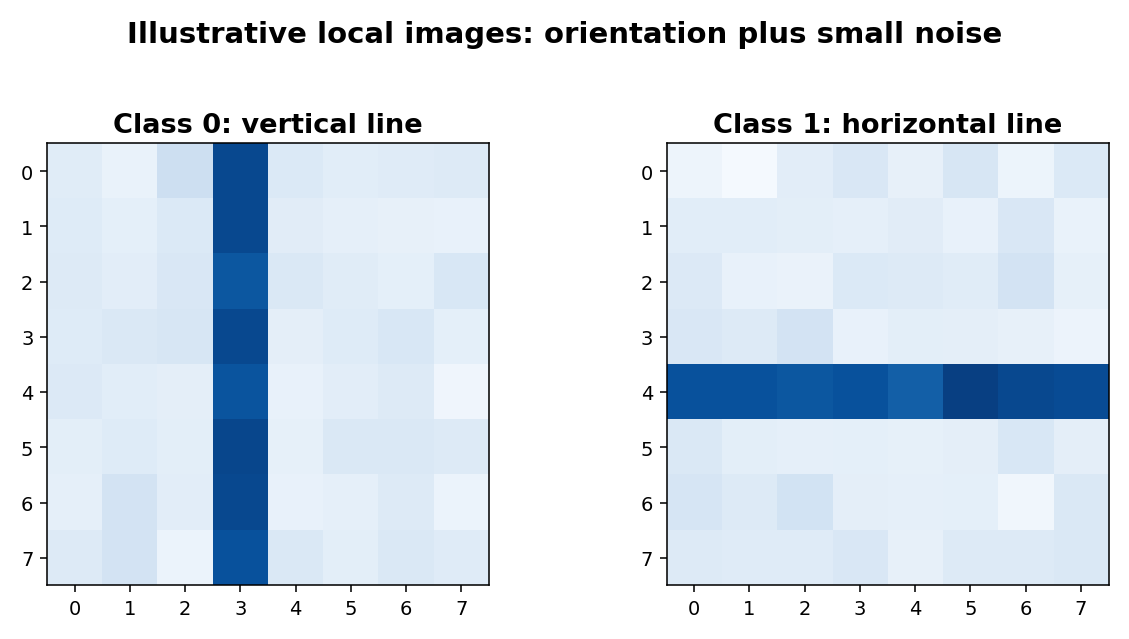

The companion creates one-channel eight-by-eight arrays. Class zero has a vertical line; class one has a horizontal line. The line location is selected from indices one through six, and Gaussian noise with scale 0.05 is added to every pixel.

| Property | Companion choice |
| --- | --- |
| Image shape | $(1,8,8)$ per example |
| Class labels | Integers 0 and 1 |
| Possible line positions | Six per orientation |
| Training examples | 160 |
| Held-out examples | 60 |
| Generation seeds | 340 for training, 341 for test |

The figures here are illustrative generated examples, not saved predictions from the companion. Separate seeds produce separate draws of location, labels, and noise, but both splits share the same small family of line templates.

A brightness-sum baseline cannot intentionally distinguish orientation because both noiseless classes contain eight bright pixels. A simple orientation-sensitive handcrafted feature is a more relevant baseline than one that ignores the distinction by design.


## Follow the architecture from local patterns to class scores

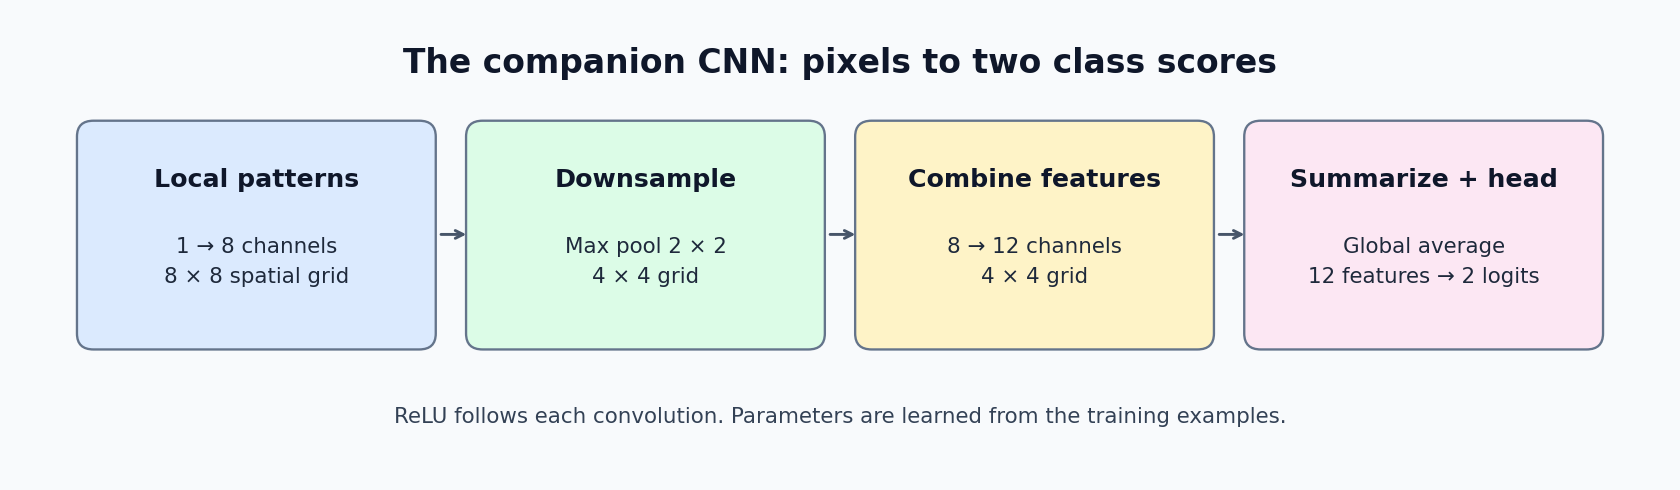

The model is:

```text
Conv2d(1 → 8, kernel 3, padding 1)
ReLU
MaxPool2d(2)
Conv2d(8 → 12, kernel 3, padding 1)
ReLU
AdaptiveAvgPool2d(1)
Flatten
Linear(12 → 2)
```

The first filters inspect grayscale neighborhoods. The second convolution mixes the first stage's eight feature channels across local spatial neighborhoods. The global average reduces each final feature map to one value before classification.

A final linear head combines these twelve summary values into two logits. The head does not need a predefined “vertical detector” coordinate. Training can distribute useful orientation information across several channels.

The architecture supplies a bias toward local, shared image processing. It does not contain a guaranteed rule for orientation until the learned parameters or an explicit hand-chosen construction define one.


## Track the shape at every stage

For a batch of size $B$:

| Stage | Output shape | What changed? |
| --- | --- | --- |
| Input | $(B,1,8,8)$ | One channel of measurements |
| First convolution | $(B,8,8,8)$ | Eight response channels |
| First ReLU | $(B,8,8,8)$ | Values, not shape |
| Max pooling | $(B,8,4,4)$ | Spatial downsampling |
| Second convolution | $(B,12,4,4)$ | Twelve deeper responses |
| Second ReLU | $(B,12,4,4)$ | Values, not shape |
| Global average pooling | $(B,12,1,1)$ | One mean per feature map |
| Flatten | $(B,12)$ | Remove singleton spatial axes |
| Class head | $(B,2)$ | One score per class |

Padding one with a three-by-three stride-one convolution preserves the spatial extent in these stages. A two-by-two stride-two pool halves eight to four. Channel count is independent of those spatial calculations.

For the training batch, $B=160$; for the test batch, $B=60$. The parameters remain identical across batch sizes. Batch dimensions count examples and are not learned filter dimensions.


## Count the parameters and distinguish them from activations

A standard convolution has $C_{out}(C_{in}K_hK_w+1)$ parameters when each output channel has a bias. A linear layer has $D_{in}D_{out}+D_{out}$.

| Learned layer | Weight count | Bias count | Total |
| --- | --- | --- | --- |
| Conv $1\to8$, $3\times3$ | 72 | 8 | 80 |
| Conv $8\to12$, $3\times3$ | 864 | 12 | 876 |
| Linear $12\to2$ | 24 | 2 | 26 |
| Complete model | 960 | 22 | 982 |

ReLU, max pooling, adaptive average pooling, and flattening contribute no learned parameters here. They still affect values, information flow, gradients, and computational work.

One first-stage output contains $8(8)(8)=512$ activation values per example. Those 512 values are produced using 80 learned parameters, not 512 independently learned location-specific coefficients.

More input resolution can increase activation memory and convolution work without changing filter parameter count. A flattened spatial classifier can additionally change its head parameter count with resolution, which is one reason to keep architecture and input shape tied together.


## Understand local patterns and receptive-field growth

A first three-by-three convolution can use a three-by-three input region for an interior output. The following pool covers two adjacent feature positions along each axis, expanding the nominal input receptive field to four-by-four.

The second three-by-three convolution works on a grid whose neighboring positions are two original pixels apart. Its nominal receptive field becomes eight-by-eight: $4+(3-1)(2)=8$ per axis.

| Stage | Nominal receptive-field extent | Spacing in original input |
| --- | --- | --- |
| First convolution | 3 | 1 |
| Two-by-two pool | 4 | 2 |
| Second convolution | 8 | 2 |

At boundaries, part of that nominal field includes padding rather than measured pixels. Global average pooling then combines all final spatial responses. The resulting class decision can use evidence from across the image.

A receptive field defines possible dependencies, not proof that every included pixel matters. A trained filter can ignore some inputs, activations can close paths, and the final head can give a feature little weight. Inspect prediction behavior rather than equating geometric coverage with learned understanding.


## Explain why global averaging is a deliberate readout choice

Adaptive average pooling to one spatial value computes the mean of each final feature map. For a map $[[1,0],[3,0]]$, the summary is one. A max summary would be three.

| Readout | What it retains | Tradeoff |
| --- | --- | --- |
| Flatten spatial maps | Position-specific feature entries | Larger head and fixed shape unless adapted |
| Global mean | Average evidence per channel | Loses explicit spatial arrangement |
| Global maximum | Strongest response per channel | Ignores how often responses occur |

The companion uses twelve means, giving a compact two-class head with 26 parameters. Flattening all twelve four-by-four maps would supply 192 features and a bias-enabled two-class head with 386 parameters.

Global averaging can support a task whose relevant pattern may occur at several locations, but it does not guarantee perfect translation invariance. Padding, downsampling, and boundary effects can change responses after a shift.

For localization or segmentation, throwing away the whole spatial grid would often remove information needed by the output. The prediction task determines the readout.


## Turn feature values into class scores and probabilities

Use a separate width-two teaching representation $h=[1,0.5]$ and head weights:

$$W=\begin{bmatrix}1&-1\\0&2\end{bmatrix},\qquad b=[0,0].$$

With row-vector convention, logits are $z=hW+b=[1,0]$. For target class zero, softmax produces probabilities approximately $[0.731059,0.268941]$ and cross-entropy is $-\ln0.731059\approx0.313262$.

| Quantity | Class 0 | Class 1 |
| --- | --- | --- |
| Logit | 1 | 0 |
| Probability | 0.731059 | 0.268941 |
| Target indicator | 1 | 0 |
| Logit derivative | -0.268941 | 0.268941 |

The companion uses a twelve-feature head rather than this two-feature construction. The example demonstrates the same classification interface without inventing the companion's trained weights or reported accuracy.

Use integer class IDs with the chosen cross-entropy implementation. A regression loss on arbitrary class numbers would teach a different target geometry and is not a substitute for this classification objective.


## Follow one update through the head and into the features

For the teaching head, let $g=[-0.268941,0.268941]$ be the logit derivative. The weight gradient is the outer product of the representation and this derivative:

$$\frac{\partial L}{\partial W}=\begin{bmatrix}-0.268941&0.268941\\-0.134471&0.134471\end{bmatrix},\qquad\frac{\partial L}{\partial b}=g.$$

At learning rate 0.1, SGD increases the correct-class weights and bias in the directions indicated by this example. Holding $h$ fixed, the updated logits are approximately $[1.060512,-0.060512]$, improving the correct-class probability.

The derivative into the feature representation is $gW^T\approx[-0.537883,0.537883]$, using the original weights. In the CNN, corresponding feature gradients continue through average pooling, ReLU, the second convolution, max pooling, and the first convolution.

Average pooling distributes a feature gradient across contributing positions according to its mean. Convolution sums contributions into shared filters. This is how a class label can adjust local feature detectors even though no label identifies a desired filter response at each pixel.


## Organize the training loop around the objective

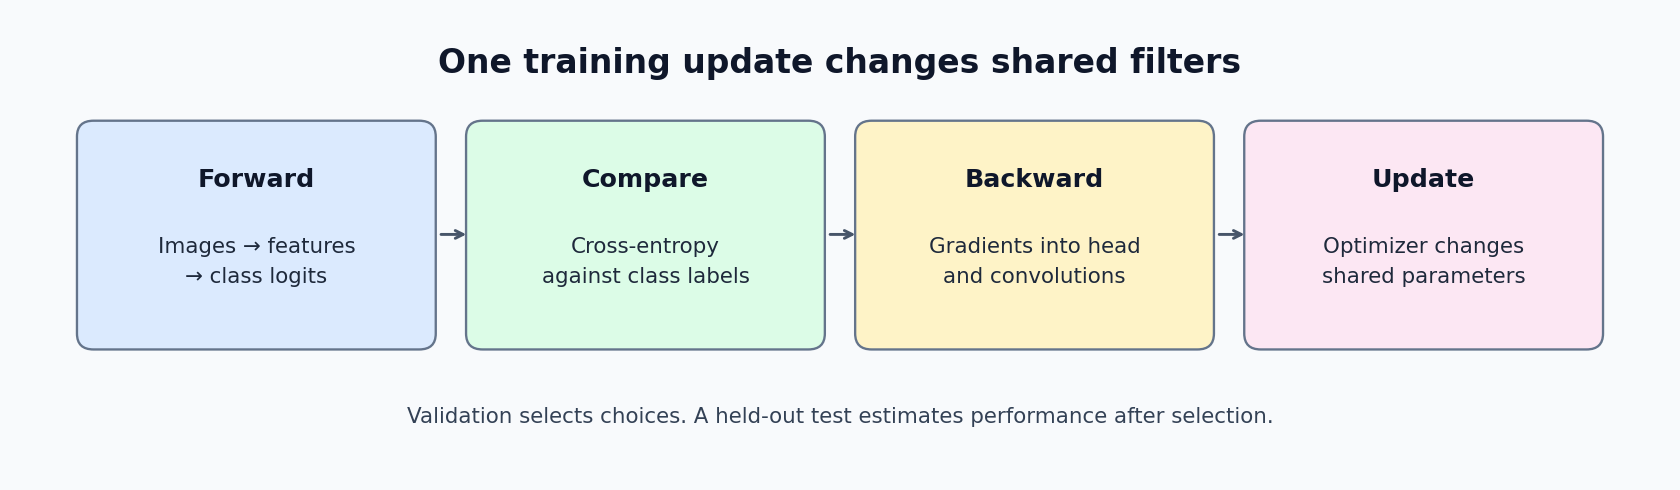

The companion runs 35 full-batch Adam updates with learning rate 0.02. Each update clears previous gradients, predicts training logits, computes mean cross-entropy, calls backward, and steps the optimizer.

| Operation | Purpose |
| --- | --- |
| Clear gradients | Avoid unintended accumulation from earlier updates |
| Forward pass | Compute current predictions |
| Loss | Compare predictions with class targets |
| Backward | Differentiate the current objective |
| Optimizer step | Change learnable parameters |

Adam is not the simple SGD calculation above; it uses accumulated gradient statistics. The teaching update isolates derivatives, while the actual companion uses the named optimizer.

Initialization, data order, preprocessing, loss reduction, and optimization settings affect results. Repeating updates on the same batch can fit a simple pattern, but the loss trajectory alone does not establish performance on new examples.

Save enough configuration to reproduce the intended input and class contract alongside parameters.


## Separate training, validation, and final testing

Training examples fit the parameters. Validation examples guide architecture choices, learning rate, checkpoint selection, or stopping. A final held-out test assesses the selected model under the defined evaluation distribution.

| Split | Permitted role | In the companion? |
| --- | --- | --- |
| Training | Parameter fitting | Yes, 160 generated examples |
| Validation | Model/configuration selection | No explicit validation split |
| Test | Assessment after choices are fixed | Yes, 60 generated examples |

The companion uses a fixed model and update count, then prints test accuracy. It does not implement validation-driven checkpoint selection. If a user repeatedly changes its settings after examining test accuracy, those test examples effectively become part of model selection.

Separately generated samples measure another draw from the same line-and-noise generator. They do not test entirely new line templates, new cameras, different image sizes, or arbitrary shapes.

For a richer experiment, add a validation split and hold out the variation that matters to the intended claim, such as locations, noise levels, sources, or time periods. Keep the final test separate from those tuning decisions.


## Define preprocessing and augmentation without changing the label

A CNN expects a consistent numerical image contract: channel order, intensity scale, spatial size, and label meaning. Training-only fitted statistics must be reused for validation and test rather than estimated from the full dataset.

Augmentation creates alternate training inputs that should preserve the target under the chosen task. For this orientation task, a small translation can preserve the label while a 90-degree rotation switches vertical and horizontal.

| Transformation | Label-preserving here? | Reason |
| --- | --- | --- |
| Small shift within the image | Usually, if the line remains visible | Orientation stays the same |
| Added small noise | Intended by the generator | Orientation stays the same |
| 90-degree rotation | No without changing the label | Orientation changes |
| Crop removing the whole line | No useful class evidence remains | Target may become unobservable |

A transformation that is useful for one image task can be wrong for another. Do not add augmentation merely because it is common in vision workflows. Define what evidence and label must survive, then inspect transformed examples.

The companion already includes noise and varied positions through its generator; it does not have a separate augmentation pipeline.


## Evaluate errors rather than relying only on one accuracy

Accuracy is the fraction of correct class predictions. If one class dominates a dataset, a majority-class baseline can obtain a deceptively high score, so inspect class counts and the confusion matrix.

| Error analysis | What it can reveal |
| --- | --- |
| By orientation | One class is systematically harder |
| By line location | Boundary or positional sensitivity |
| By noise level | Dependence on clean inputs |
| By image source | Domain shift |
| Against an orientation baseline | Whether learned complexity adds value |

The companion reports one held-out accuracy after training. These notes do not invent its value or claim that the finite-loss assertion establishes an accuracy threshold.

For models with dropout or batch normalization, training and evaluation modes affect behavior. In this particular sequential CNN, those layers are absent, so switching modes does not alter those nonexistent mechanisms. Still, an explicit evaluation mode and no-gradient prediction are clear habits when extending the architecture.

Compare uncertainty and errors on representative data, not just visually appealing filters or a favorable training loss.


## Diagnose training problems before changing the architecture

| Symptom | First investigation |
| --- | --- |
| Shape error in the classifier | Trace pooling and head input width |
| Loss does not improve | Check labels, scales, gradients, and learning rate |
| Training improves but test does not | Check overfitting and split distribution |
| Orientation flips after augmentation | Check whether the label should also change |
| Shifts alter predictions | Inspect boundaries, pooling, and location coverage |
| Parameters appear unexpectedly large | Check flattening and channel dimensions |

A useful debugging sequence is to inspect inputs and targets, verify one forward shape trace, check a loss calculation, and confirm that parameters receive gradients. Fitting a tiny subset can test whether the optimization interface works, but it is not a generalization assessment.

Broader or deeper models may improve a valid task, yet cannot repair mislabeled images, leaked test choices, or an input scale that differs between training and evaluation.


## Practice the architecture and retain the full workflow

1. What shape follows the first pool for four companion-style examples?
2. How many learned parameters are in the complete companion model?
3. Why does a global mean head have fewer parameters than flattening twelve four-by-four maps?
4. Is a 90-degree rotation label-preserving for vertical-versus-horizontal classification?
5. Does the companion perform validation-based checkpoint selection?

**Answers.** The shape is $(4,8,4,4)$. The model has 982 learned parameters. Averaging reduces 192 spatial feature entries to twelve channel summaries before the linear head. A 90-degree rotation changes the orientation label. The companion uses fixed settings and a test split, without an explicit validation checkpoint-selection loop.

**Remember:** trace pixels through local filters, activations, spatial reductions, feature summaries, and logits; then use a correctly defined loss and split to learn and evaluate the model. Architecture, training, and evidence of generalization are separate parts of the explanation.

Continue with [Important CNN Designs](35_Important_CNN_Designs_Notes.ipynb) to compare structural choices for depth, feature reuse, and computation.
